# Initialize

In [1]:
#General packages
from IPython.display import clear_output #import of a single funtcion
import sys #system related packages
import os #better path and file handling
import pickle #saving and loading objects

#Tables, numbers etc
import pandas as pd #tables
import numpy as np #arrays
import scipy #sciency functions
from sklearn import mixture #For gaussian mixture model

#Plotting packages
import matplotlib.pyplot as plt #Main plotting
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D
import seaborn as sbn #nicer plots

#RNA-seq analysis
import scanpy as sc #Main package for scRNA-seq analysis
import scanpy.external as sce #some more functions for scanpy
import bbknn #batch correction

#Import some custom helper functions for plotting
path_skin_scripts = '/mnt/p/users/Karl/Python/Projects'
sys.path.append(path_skin_scripts)
from Skin_scripts import *

import warnings
warnings.simplefilter("ignore")

path_skin_scripts = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao'
sys.path.append(path_skin_scripts)
from Hierarchy_functions import *

/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/opt/miniforge3/envs/karlpy/lib/python3.12/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


# Read

In [2]:
path = '/mnt/p/users/Karl/Hao/'

In [3]:
adata = sc.read_h5ad(os.path.join(path, 'adata_merged_I_20260209.h5ad'))
adata

AnnData object with n_obs × n_vars = 463503 × 82304
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontolo

# Recalculate QC

In [4]:
sc.pp.calculate_qc_metrics(adata, layer = 'raw_counts', inplace = True)

# Make statistics for all together

In [5]:
df = adata.obs.copy()

## Total counts

In [6]:
df["log1p_counts_mean"] = (
    df["log1p_total_counts"]
    - df.groupby("donor_id_running")["log1p_total_counts"].transform("mean")
)
df["log1p_counts_median"] = (
    df["log1p_total_counts"]
    - df.groupby("donor_id_running")["log1p_total_counts"].transform("median")
)
df["log1p_counts_z"] = (
    df["log1p_total_counts"]
    - df.groupby("study_id")["log1p_total_counts"].transform("mean")
) / df.groupby("study_id")["log1p_total_counts"].transform("std")



In [7]:
df['Cell_Type'] = df['integrated_annotation_L3'].str.split(' - ').str[:2].str.join(' - ').replace('nan', pd.NA)
df['Cell_Type'] = df['Cell_Type'].fillna(df['integrated_annotation_L2'].str.split(' - ').str[0].replace('KC', 'KC - IFE')).replace('nan', pd.NA)
df['Cluster'] = df['integrated_annotation_L3'].replace('nan', pd.NA).astype('object').fillna(df['integrated_annotation_L2'].apply(lambda x: x.replace('KC', 'KC - IFE')).replace('nan', pd.NA).astype('object'))
df['Cell_Type'].unique()

array(['KC - IFE', 'MYE', 'VEC', 'FIB', 'KC - HFGland', 'MUR', 'LEC',
       'MAST', 'LYM', 'MEL', 'SC', <NA>], dtype=object)

In [8]:
remove_clusters = ['KC - IFE - 19: uHF', 'KC - IFE - 23: HF_Anagen', 'KC - IFE - 27: Gland_Channel_2', 'KC - IFE - 21: HF_2', 'KC - IFE - 24: SG_1', 'KC - IFE - 26: Gland_Channel_1', 'KC - IFE - 22: HF_3', 'KC - IFE - 20: HF_1']#, 'IFE - 32: MIX_KC/Imm', 'IFE - 33: MIX_KC/FIB', 'IFE - 34: MIX_KC/vSM', 'IFE - 35: MIX_KC/EC', 'IFE - 31: Melanocytes']
df = df[~df['Cluster'].isin(remove_clusters)].copy()

In [9]:
comparisons = {
 'FIB': ['FIB - 1', 'FIB - 2', 'FIB - 21'],
 'KC - IFE': ['KC - IFE - 12'],
 'KC - HFGland': ['KC - HFGland - 0', 'KC - HFGland - 3', 'KC - HFGland - 14', 'KC - HFGland - 15', 'KC - HFGland - 20', 'KC - HFGland - 24'],
 'LEC': ['LEC - 0', 'LEC - 3', 'LEC - 6', 'LEC - 9'],
 'LYM': [],
 'MAST': ['MAST - 0', 'MAST - 1', 'MAST - 2', 'MAST - 3', 'MAST - 5'],
 'MEL': ['MEL - 0', 'MEL - 1', 'MEL - 8'],
 'MUR': ['MUR - 6'],
 'MYE': ['MYE - 0', 'MYE - 2', 'MYE - 5', 'MYE - 6'],
 'SC': ['SC - 0', 'SC - 1', 'SC - 2', 'SC - 3', 'SC - 8', 'SC - 13'],
 'VEC': ['VEC - 0']}

In [10]:
from scipy.stats import wilcoxon

x = 'Cluster'
y = 'log1p_total_counts'

wilcoxon_results = {}

for cell, clusters in comparisons.items():
    wilcoxon_results[cell] = {}
    for cluster in clusters:
        cluster = [c for c in df[x].dropna().unique() if c.startswith(cluster + ':')][0]
        effects = []
        
        for donor, sub in df.groupby("donor_id_running"):
            c1 = sub.loc[sub[x] == cluster, y]
            c2 = sub.loc[sub[x] != cluster, y]
            
            if len(c1) > 20 and len(c2) > 20:
                effects.append(c1.median() - c2.median())
        
        wilcoxon_results[cell][cluster] = wilcoxon(effects)

In [11]:
from statsmodels.stats.multitest import multipletests

records = []
for cell, clusters in wilcoxon_results.items():
    for cluster, res in clusters.items():
        records.append({
            "cell": cell,
            "cluster": cluster,
            "statistic": res.statistic,
            "pval": res.pvalue if np.isfinite(res.pvalue) else 1})

df_results = pd.DataFrame(records)

df_results["pval_adj"] = multipletests(df_results["pval"], method="fdr_bh")[1]

for _, row in df_results.iterrows():
    wilcoxon_results[row["cell"]][row["cluster"]] = {
        "statistic": row["statistic"],
        "pval": row["pval"],
        "pval_adj": row["pval_adj"]}
df_results['Significant'] = np.where(df_results['pval_adj'] < 0.05, True, False)

In [12]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/QC'

In [13]:
df_results.to_csv(os.path.join(fig_path, 'Low_Quality_QC_wilcoxon_corrected(BH).csv'))

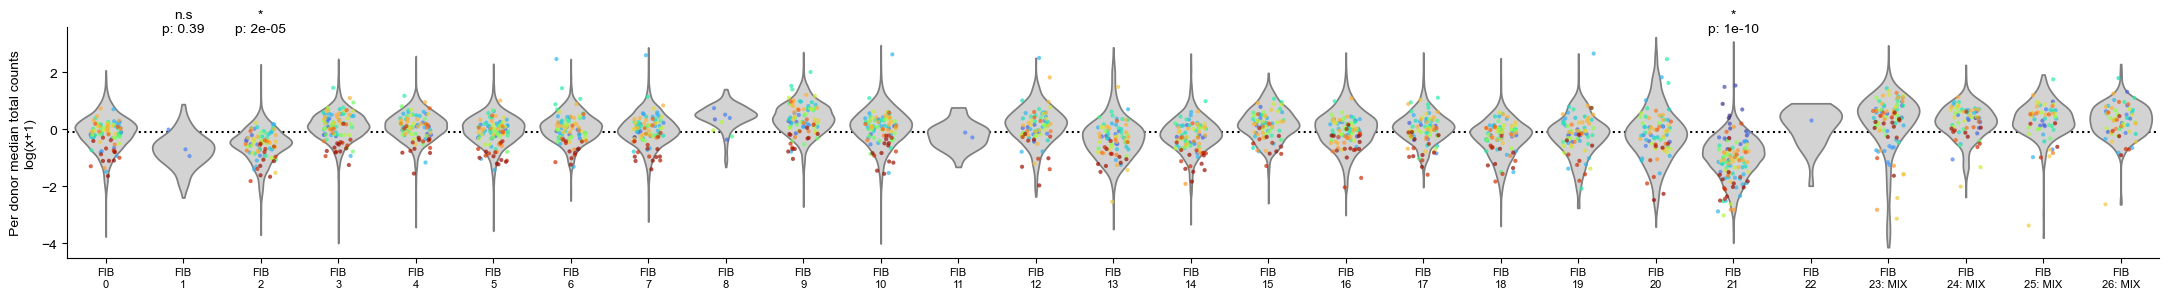

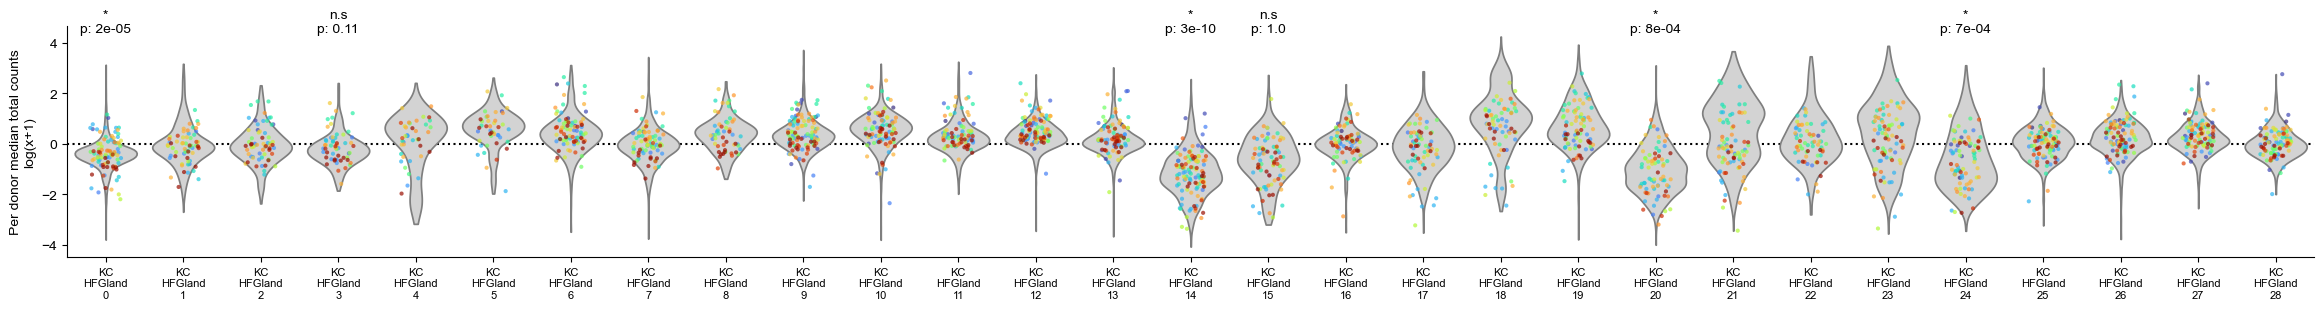

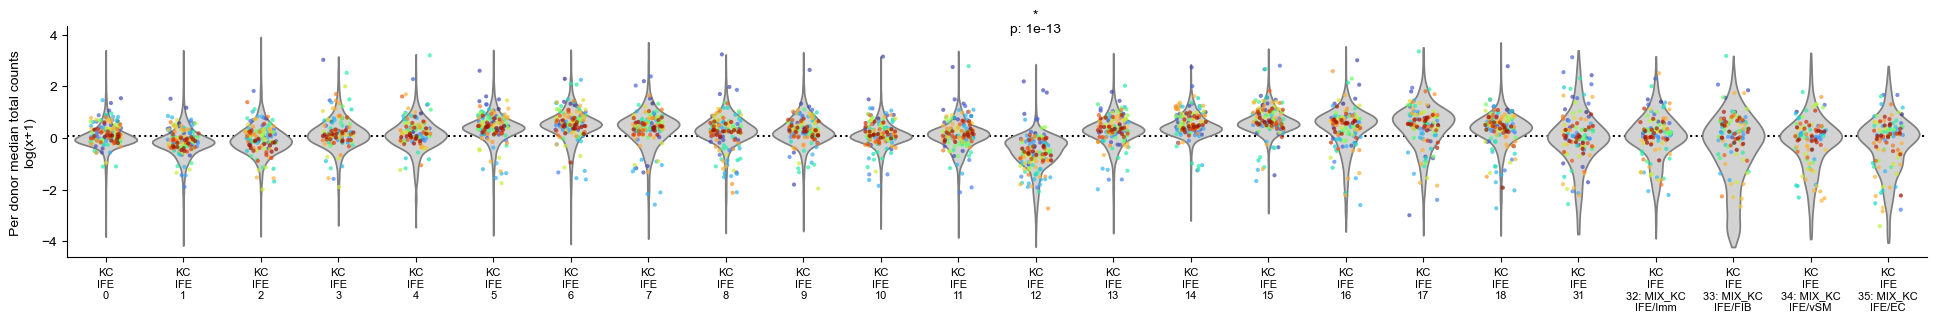

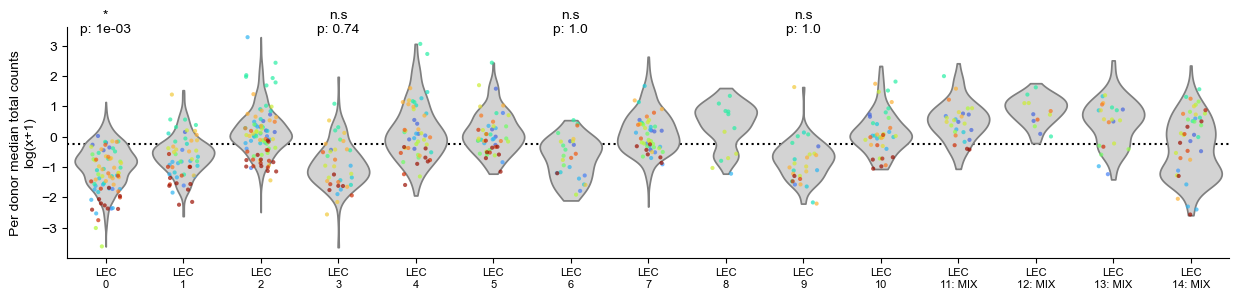

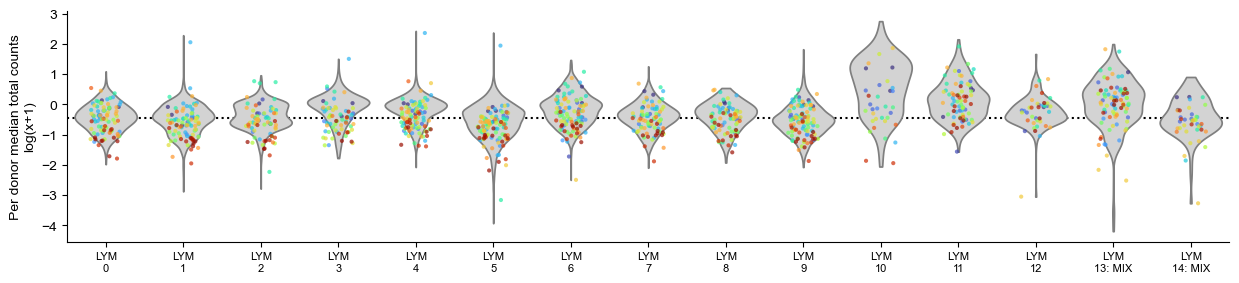

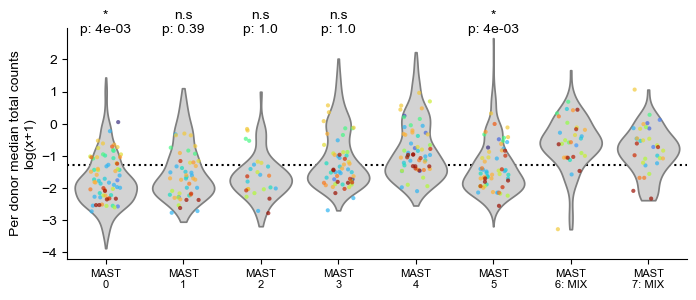

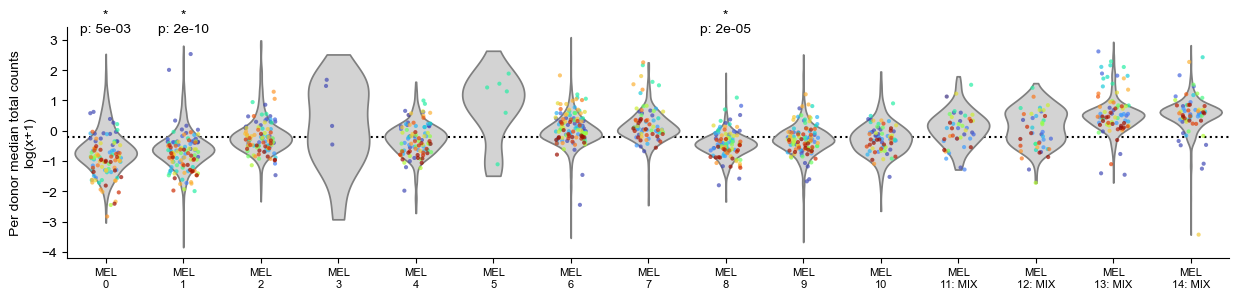

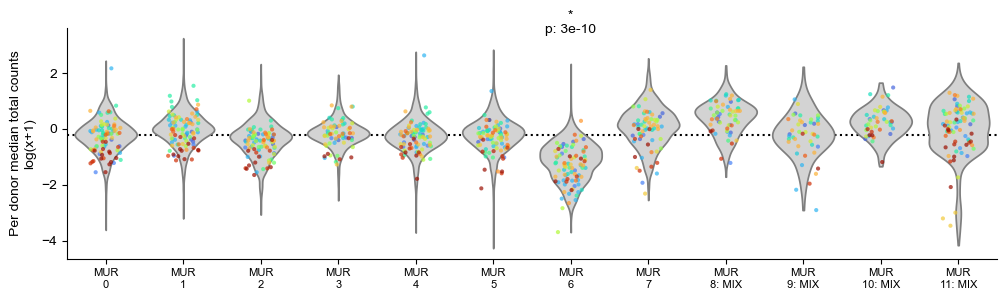

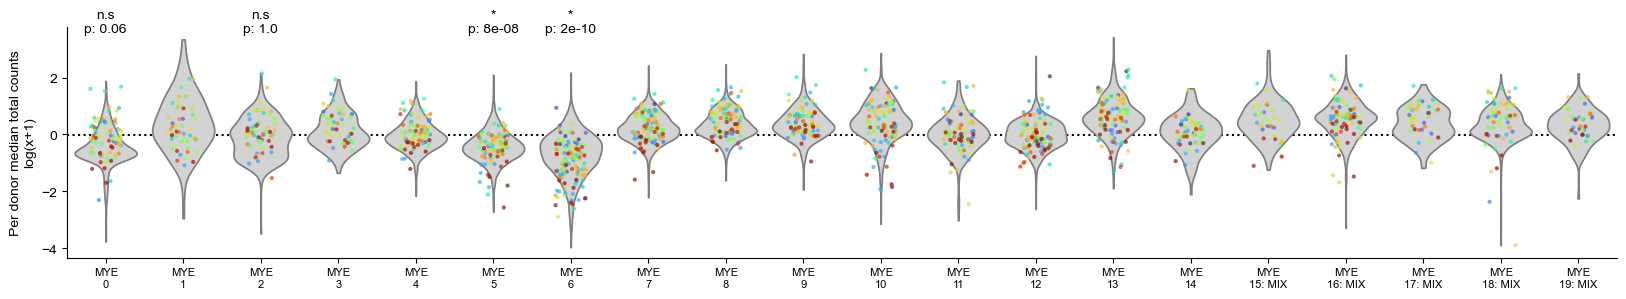

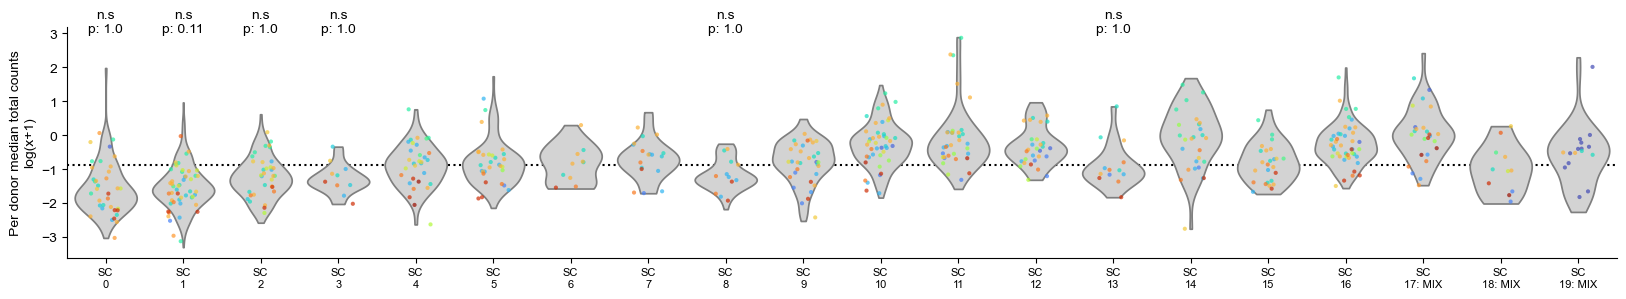

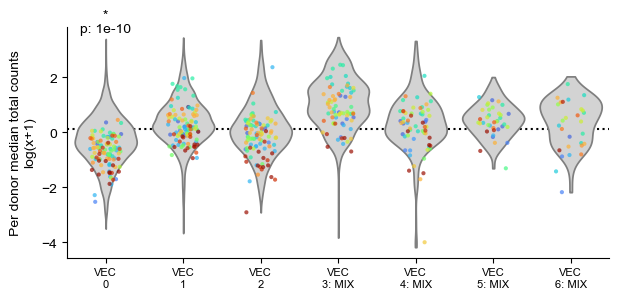

In [14]:
s = 3
type_col = 'Cell_Type'

x = 'Cluster'
y = 'log1p_counts_median'
#cell_type = 'Fibroblast'
for cell_type in natsorted(df[type_col].dropna().unique()):
    tmp_df = df[df[type_col]==cell_type]
    
    order = natsorted([c for c in tmp_df[x].unique() if c != 'nan'])
    fig, ax = initialize_subplots(1, ncols = 1, figsize_multiplier = (1*len(order), 3), gridspec_kw = dict(hspace = 0.15), print_help=False)
    
    sbn.violinplot(data = tmp_df, x = x, y = y, ax = ax, cut = 0, density_norm = 'width', order = order, color = 'lightgray', inner = None)
        
    medians_for_plotting = tmp_df.groupby(['donor_id_running', x, 'study_id'], observed = True)[y].median().to_frame().reset_index()
    sbn.stripplot(data=medians_for_plotting, x=x, y=y, order=order, dodge=False, jitter=0.2, s=s, hue='study_id', edgecolor=None, linewidth=0, ax=ax, alpha = 0.7, palette = 'turbo')

    ax.legend('', frameon = False)
    ax.axhline(tmp_df[y].mean(), ls = ':', color = 'k', zorder = -10)
        
    ax.set_xticklabels([t.get_text().split(':')[0].replace(' - ', '\n') if 'MIX' not in t.get_text() else t.get_text().split('(')[0].replace(' - ', '\n') for t in ax.get_xticklabels()], rotation = 0, fontsize = 8)
    ax.set_xlabel('')
    
    for _, row in df_results[df_results['cell'] == cell_type].iterrows():
        cl = int(row['cluster'].split(f'{cell_type} - ')[-1].split(':')[0])
        if row['Significant']:
            p = f"{row['pval_adj']:1.0e}"
            sig = '*'
        else:
            p = np.round(row['pval_adj'], decimals=2)
            sig = 'n.s'
        ax.text(cl, ax.get_ylim()[1] * 0.95, s = f'{sig}\np: {p}', ha = 'center')
    [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
    
    ax.set_ylabel('Per donor median total counts\nlog(x+1)')
    #[fig.savefig(os.path.join(fig_path, f'QC_{cell_type}.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

Figure legend:

For each selected subcluster, transcript counts were compared against all remaining cells within the same donor. log1p_total_counts values were donor-centered by subtracting the donor median, and violin plots show the distribution of centered values per cluster within each major cell type. Colored points indicate per-donor cluster medians, with donors colored by study. Statistical significance was assessed by computing, for each donor, the median difference in log1p_total_counts between the cluster of interest and all other cells, followed by a Wilcoxon signed-rank test across donors and Benjamini–Hochberg correction across tested clusters.

OR

Figure legend:

Donor-centered log1p_total_counts (median-subtracted) are shown per cluster within each cell type. Points represent per-donor medians (colored by study). For each cluster, donor-level median differences (cluster vs. all other cells) were tested using a Wilcoxon signed-rank test with FDR correction.

Methods:

To evaluate whether selected subclusters showed reduced transcript counts, log1p_total_counts was centered within donors by subtracting the donor-specific median. For each cluster of interest, donor-level effect sizes were calculated as the difference between the donor median of cells in that cluster and the donor median of all other cells from the same donor. Only donors with more than 20 cells in both groups were included. These donor-level paired effects were tested against zero using a Wilcoxon signed-rank test, and resulting p-values were adjusted for multiple testing using the Benjamini–Hochberg procedure. Distributions of donor-centered values were visualized per cluster, with overlaid per-donor medians colored by study.

## Number of genes

In [15]:
from scipy.stats import wilcoxon

x = 'Cluster'
y = 'log1p_n_genes_by_counts'

wilcoxon_results_features = {}

for cell, clusters in comparisons.items():
    wilcoxon_results_features[cell] = {}
    for cluster in clusters:
        cluster = [c for c in df[x].dropna().unique() if c.startswith(cluster + ':')][0]
        effects = []
        
        for donor, sub in df.groupby("donor_id_running"):
            c1 = sub.loc[sub[x] == cluster, y]
            c2 = sub.loc[sub[x] != cluster, y]
            
            if len(c1) > 20 and len(c2) > 20:
                effects.append(c1.median() - c2.median())
        
        wilcoxon_results_features[cell][cluster] = wilcoxon(effects)

In [16]:
from statsmodels.stats.multitest import multipletests

records = []
for cell, clusters in wilcoxon_results_features.items():
    for cluster, res in clusters.items():
        records.append({
            "cell": cell,
            "cluster": cluster,
            "statistic": res.statistic,
            "pval": res.pvalue if np.isfinite(res.pvalue) else 1})

df_results = pd.DataFrame(records)

df_results["pval_adj"] = multipletests(df_results["pval"], method="fdr_bh")[1]

for _, row in df_results.iterrows():
    wilcoxon_results_features[row["cell"]][row["cluster"]] = {
        "statistic": row["statistic"],
        "pval": row["pval"],
        "pval_adj": row["pval_adj"]}
df_results['Significant'] = np.where(df_results['pval_adj'] < 0.05, True, False)

In [20]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/QC'

In [21]:
df_results.to_csv(os.path.join(fig_path, 'Low_Quality_QC_wilcoxon_corrected(BH)_nFeatures.csv'))

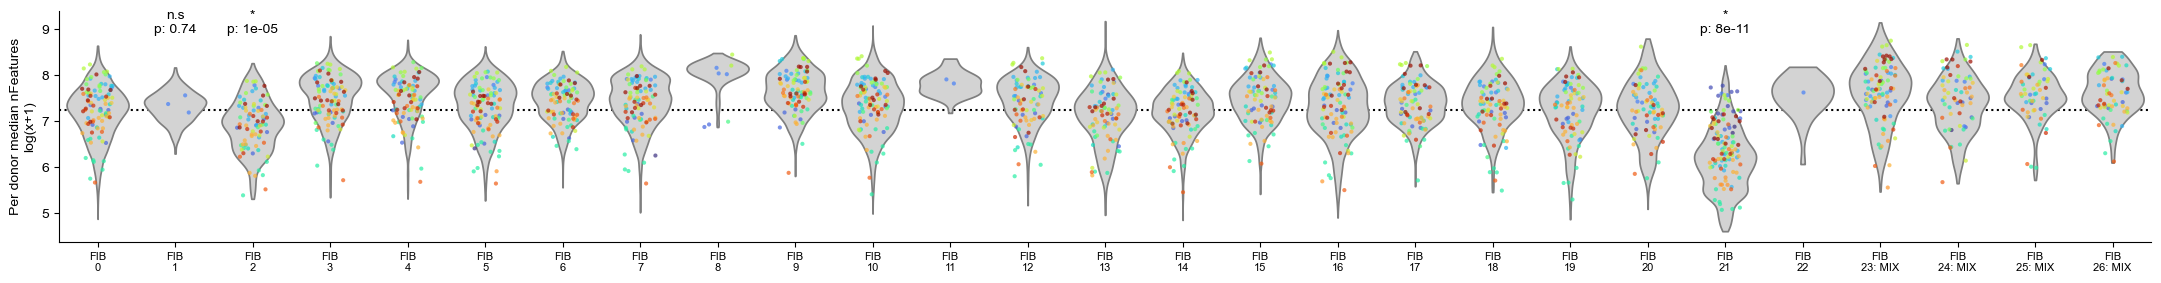

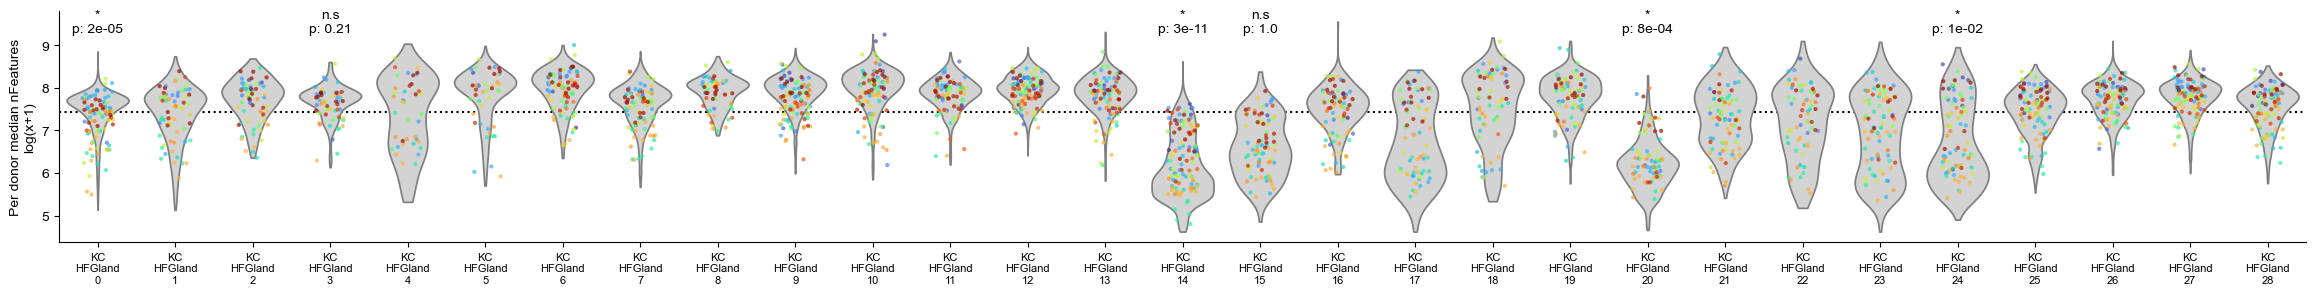

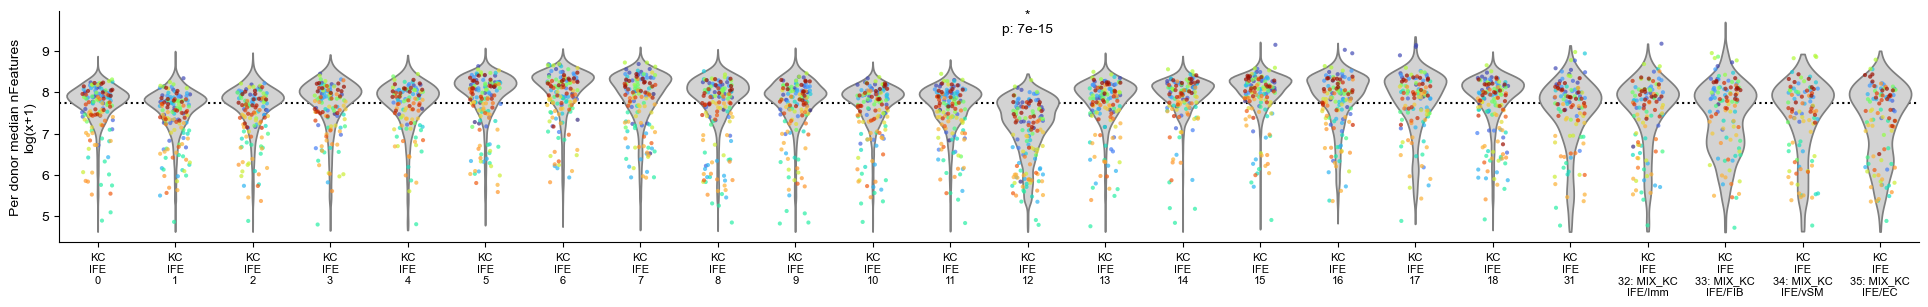

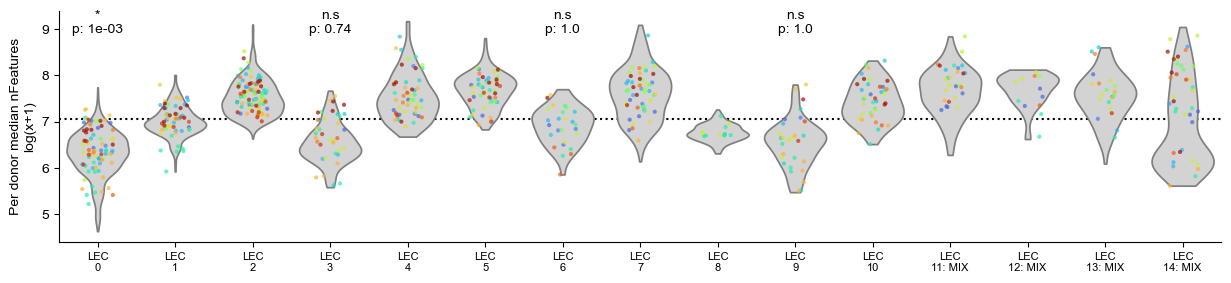

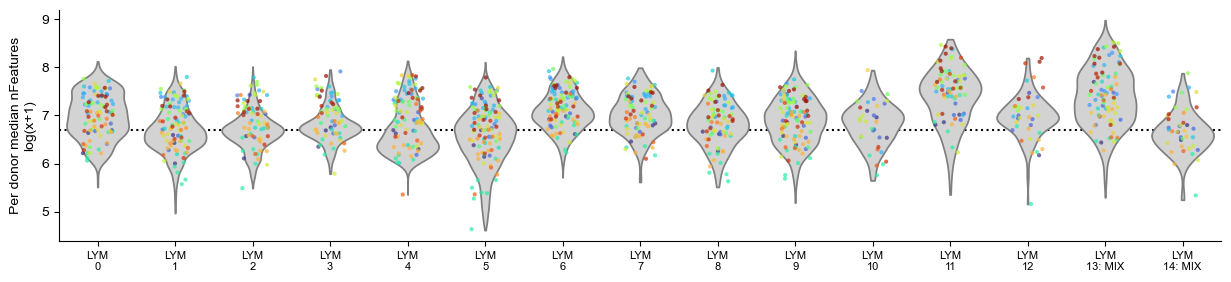

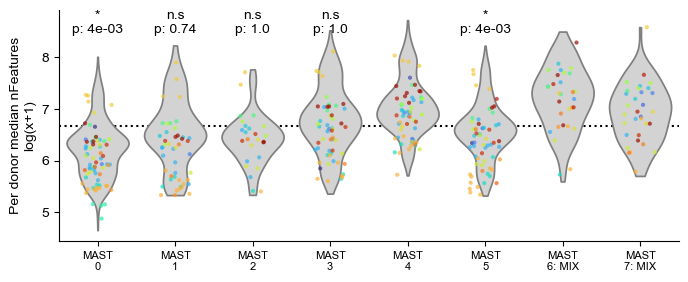

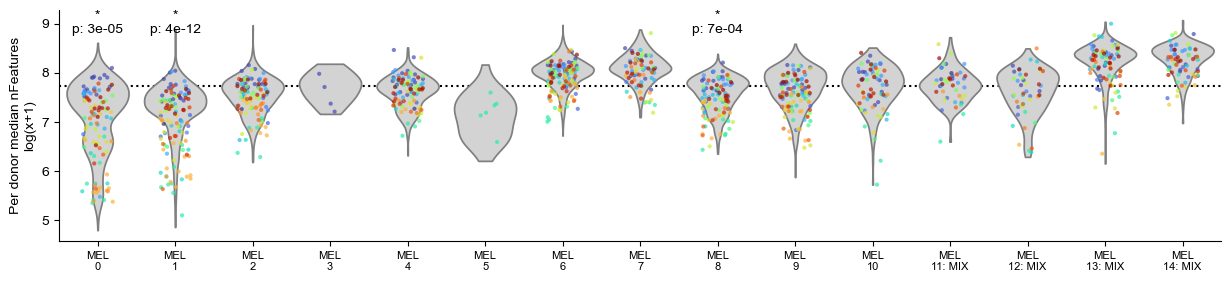

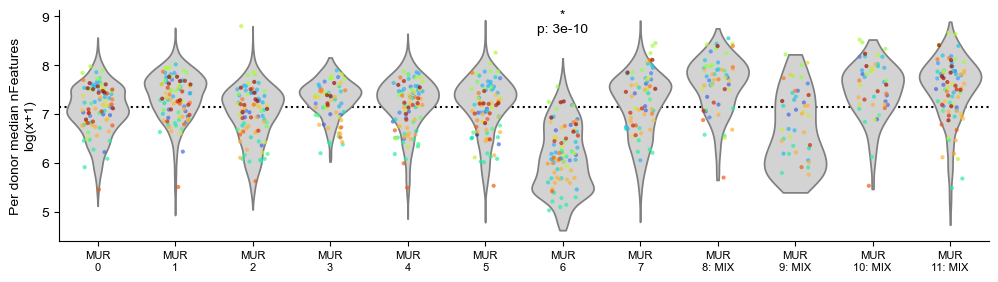

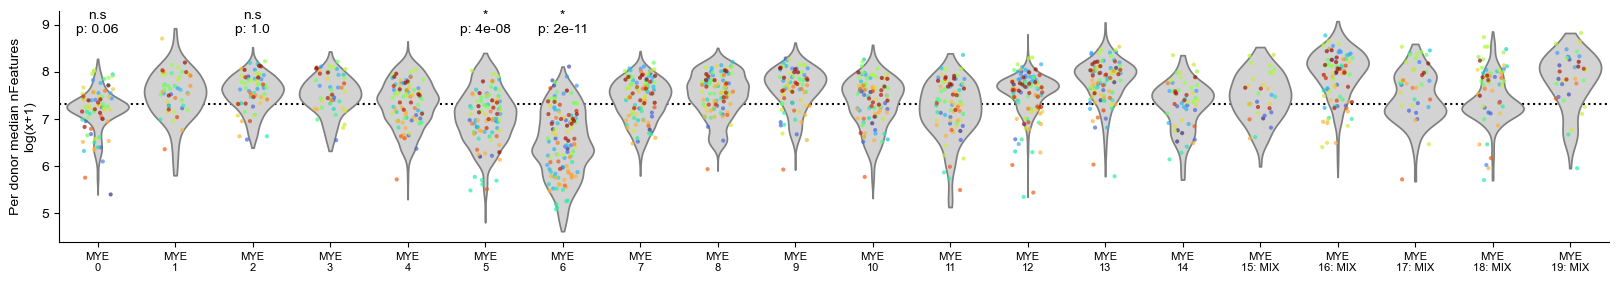

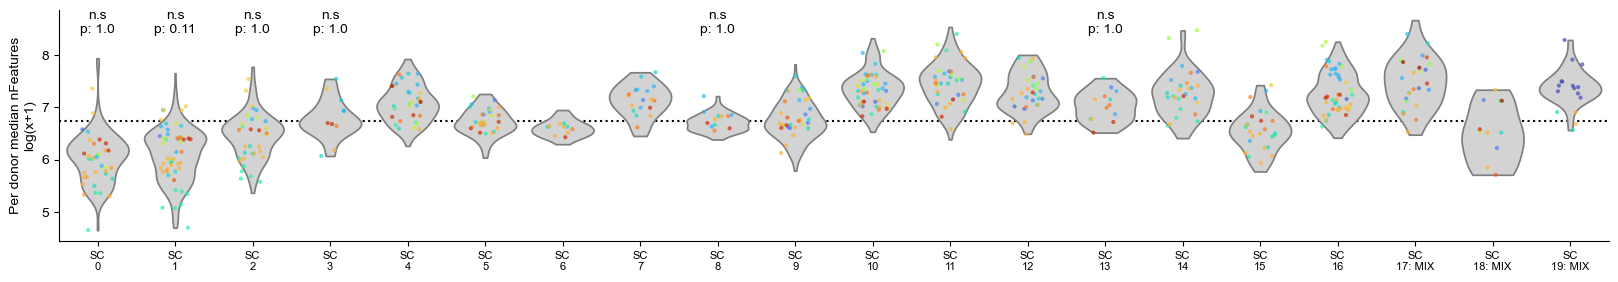

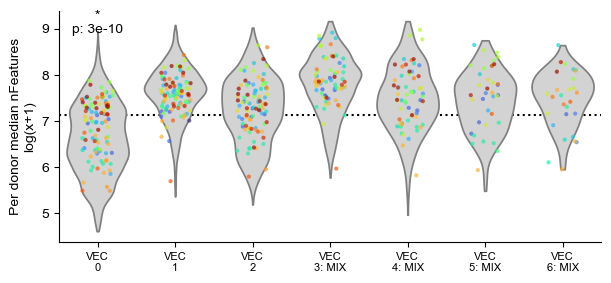

In [17]:
s = 3
type_col = 'Cell_Type'

x = 'Cluster'
y = 'log1p_n_genes_by_counts'
#cell_type = 'Fibroblast'
for cell_type in natsorted(df[type_col].dropna().unique()):
    tmp_df = df[df[type_col]==cell_type]
    
    order = natsorted([c for c in tmp_df[x].unique() if c != 'nan'])
    fig, ax = initialize_subplots(1, ncols = 1, figsize_multiplier = (1*len(order), 3), gridspec_kw = dict(hspace = 0.15), print_help=False)
    
    sbn.violinplot(data = tmp_df, x = x, y = y, ax = ax, cut = 0, density_norm = 'width', order = order, color = 'lightgray', inner = None)
        
    medians_for_plotting = tmp_df.groupby(['donor_id_running', x, 'study_id'], observed = True)[y].median().to_frame().reset_index()
    sbn.stripplot(data=medians_for_plotting, x=x, y=y, order=order, dodge=False, jitter=0.2, s=s, hue='study_id', edgecolor=None, linewidth=0, ax=ax, alpha = 0.7, palette = 'turbo')

    ax.legend('', frameon = False)
    ax.axhline(tmp_df[y].mean(), ls = ':', color = 'k', zorder = -10)
        
    ax.set_xticklabels([t.get_text().split(':')[0].replace(' - ', '\n') if 'MIX' not in t.get_text() else t.get_text().split('(')[0].replace(' - ', '\n') for t in ax.get_xticklabels()], rotation = 0, fontsize = 8)
    ax.set_xlabel('')

    [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]

    for _, row in df_results[df_results['cell'] == cell_type].iterrows():
        cl = int(row['cluster'].split(f'{cell_type} - ')[-1].split(':')[0])
        if row['Significant']:
            p = f"{row['pval_adj']:1.0e}"
            sig = '*'
        else:
            p = np.round(row['pval_adj'], decimals=2)
            sig = 'n.s'
        ax.text(cl, ax.get_ylim()[1] * 0.95, s = f'{sig}\np: {p}', ha = 'center')
    [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
    
    ax.set_ylabel('Per donor median nFeatures\nlog(x+1)')
    #[fig.savefig(os.path.join(fig_path, f'QC_{cell_type}_nFeatures.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Dendrogram L1

In [16]:
from scipy.cluster.hierarchy import linkage, dendrogram
def make_dendrogram(adata, cluster, pca_name, linkage_method, cor_method, ax=None, full_cmap=None, return_dendrogram=False, **kwargs):
    """
    Computes and plots a dendrogram for the clusters in an AnnData object.

    Uses Scanpy's dendrogram calculation and Matplotlib for layout. Helps visualize
    global relationships between clusters in a single resolution.

    Args:
        adata (AnnData): The annotated data matrix.
        cluster (str): Name of the column in `adata.obs` representing the clustering.
        pca_name (str): The name of the PCA representation to use for distance calculation.
        linkage_method (str): Linkage algorithm to use (e.g., 'complete', 'average', 'ward').
        cor_method (str): Correlation calculation method (e.g., 'pearson', 'spearman').
        ax (matplotlib.axes.Axes, optional): Axes object for plotting.
        full_cmap (dict, optional): Mapping of cluster names to colors {cluster_name: color}.
        return_dendrogram (bool, optional): Whether to return the dendrogram dictionary.
        **kwargs: Additional arguments passed to `sc.tl.dendrogram`.

    Returns:
        dict: The dendrogram dictionary if `return_dendrogram` is True, else None.
    """
    sc.tl.dendrogram(adata, groupby=cluster, use_rep=pca_name, linkage_method=linkage_method, cor_method=cor_method, **kwargs)

    if not ax:
        fig, ax = plt.subplots(figsize = (3, 10))
    Z = adata.uns[f'dendrogram_{cluster}']['linkage']
    dendro = dendrogram(Z, labels=adata.obs[cluster].cat.categories, color_threshold=0, orientation = 'left', ax = ax, above_threshold_color='black')
    
    [ax.spines[spine].set_visible(False) for spine in ax.spines]
    ax.set_xticks([])
    
    labels = ax.get_ymajorticklabels()
    for lbl in labels:
        cluster_name = lbl.get_text()
        if full_cmap is not None:
            if cluster_name in full_cmap:
                lbl.set_color(full_cmap[cluster_name])
        lbl.set_fontweight('bold')
        lbl.set_fontsize(9)
    
    ax.set_title(f'{cluster} dendrogram\npca: {pca_name}; linkage: {linkage_method}; correlation: {cor_method}', fontdict = dict(size = 9))
    if return_dendrogram:
        return dendro

In [262]:
out_path = '/mnt/p/users/Karl/Python/Projects/Human_skin_Hao/Final_hierarchies'
os.listdir(out_path)

['Clustering_hierarchies_Lymphocytes.ipynb',
 '.ipynb_checkpoints',
 'LYM_hierarchies.h5ad',
 'MYE_hierarchies.h5ad',
 'KC_HF_Gland_hierarchies.h5ad',
 'Clustering_hierarchies_KC_HF_Gland_continue_plotting.ipynb',
 'temp_hierarchy_render.png',
 'SC_hierarchies.h5ad',
 'VEC_hierarchies.h5ad',
 'LEC_hierarchies.h5ad',
 'FIB_hierarchies.h5ad',
 'MEL_hierarchies.h5ad',
 'MAST_hierarchies.h5ad',
 'MUR_hierarchies.h5ad']

In [264]:
cells = []
for f in os.listdir(out_path):
    if '.h5ad' in f:
        print(f)
        clear_output(wait = True)
        cells.append(sc.read_h5ad(os.path.join(out_path, f)).obs_names.tolist())

MUR_hierarchies.h5ad


In [274]:
cells = [cell for cell_type_cells in cells for cell in cell_type_cells]
cells = np.array(cells)

In [293]:
tmp_data = adata.copy()
tmp_data.obs_names = tmp_data.obs['integrated_barcode']
tmp_data = tmp_data[cells].copy()
tmp_data

AnnData object with n_obs × n_vars = 434897 × 82304
    obs: 'study_id', 'experiment_id', 'institute', 'author_batch_notes', 'organism', 'organism_ontology_term_id', 'donor_id', 'donor_id_running', 'sex_ontology_term', 'sex_ontology_term_id', 'ethnicity_1', 'ethnicity_2', 'ethnicity_details', 'self_reported_ethnicity_ontology_term_id', 'genotype', 'age_years', 'age_range', 'development_stage_ontology_term', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'disease_status', 'treatment_status', 'smoking_status', 'smoking_history', 'bmi', 'systemic_disorder', 'autoimmune_component', 'menopause_status', 'puperty_status', 'sun_exposure', 'skin_tone', 'skin_care', 'manner_of_death', 'sample_id', 'sample_id_running', 'sample_source', 'sample_collection_method', 'sampled_site_condition', 'anatomical_region_level_1', 'anatomical_region_level_2', 'anatomical_region_level_3', 'anatomical_region', 'tissue_type', 'tissue_free_text', 'tissue_ontology_term', 'tissue_ontolo

ax = axes[ix // ncols, ix % ncols]


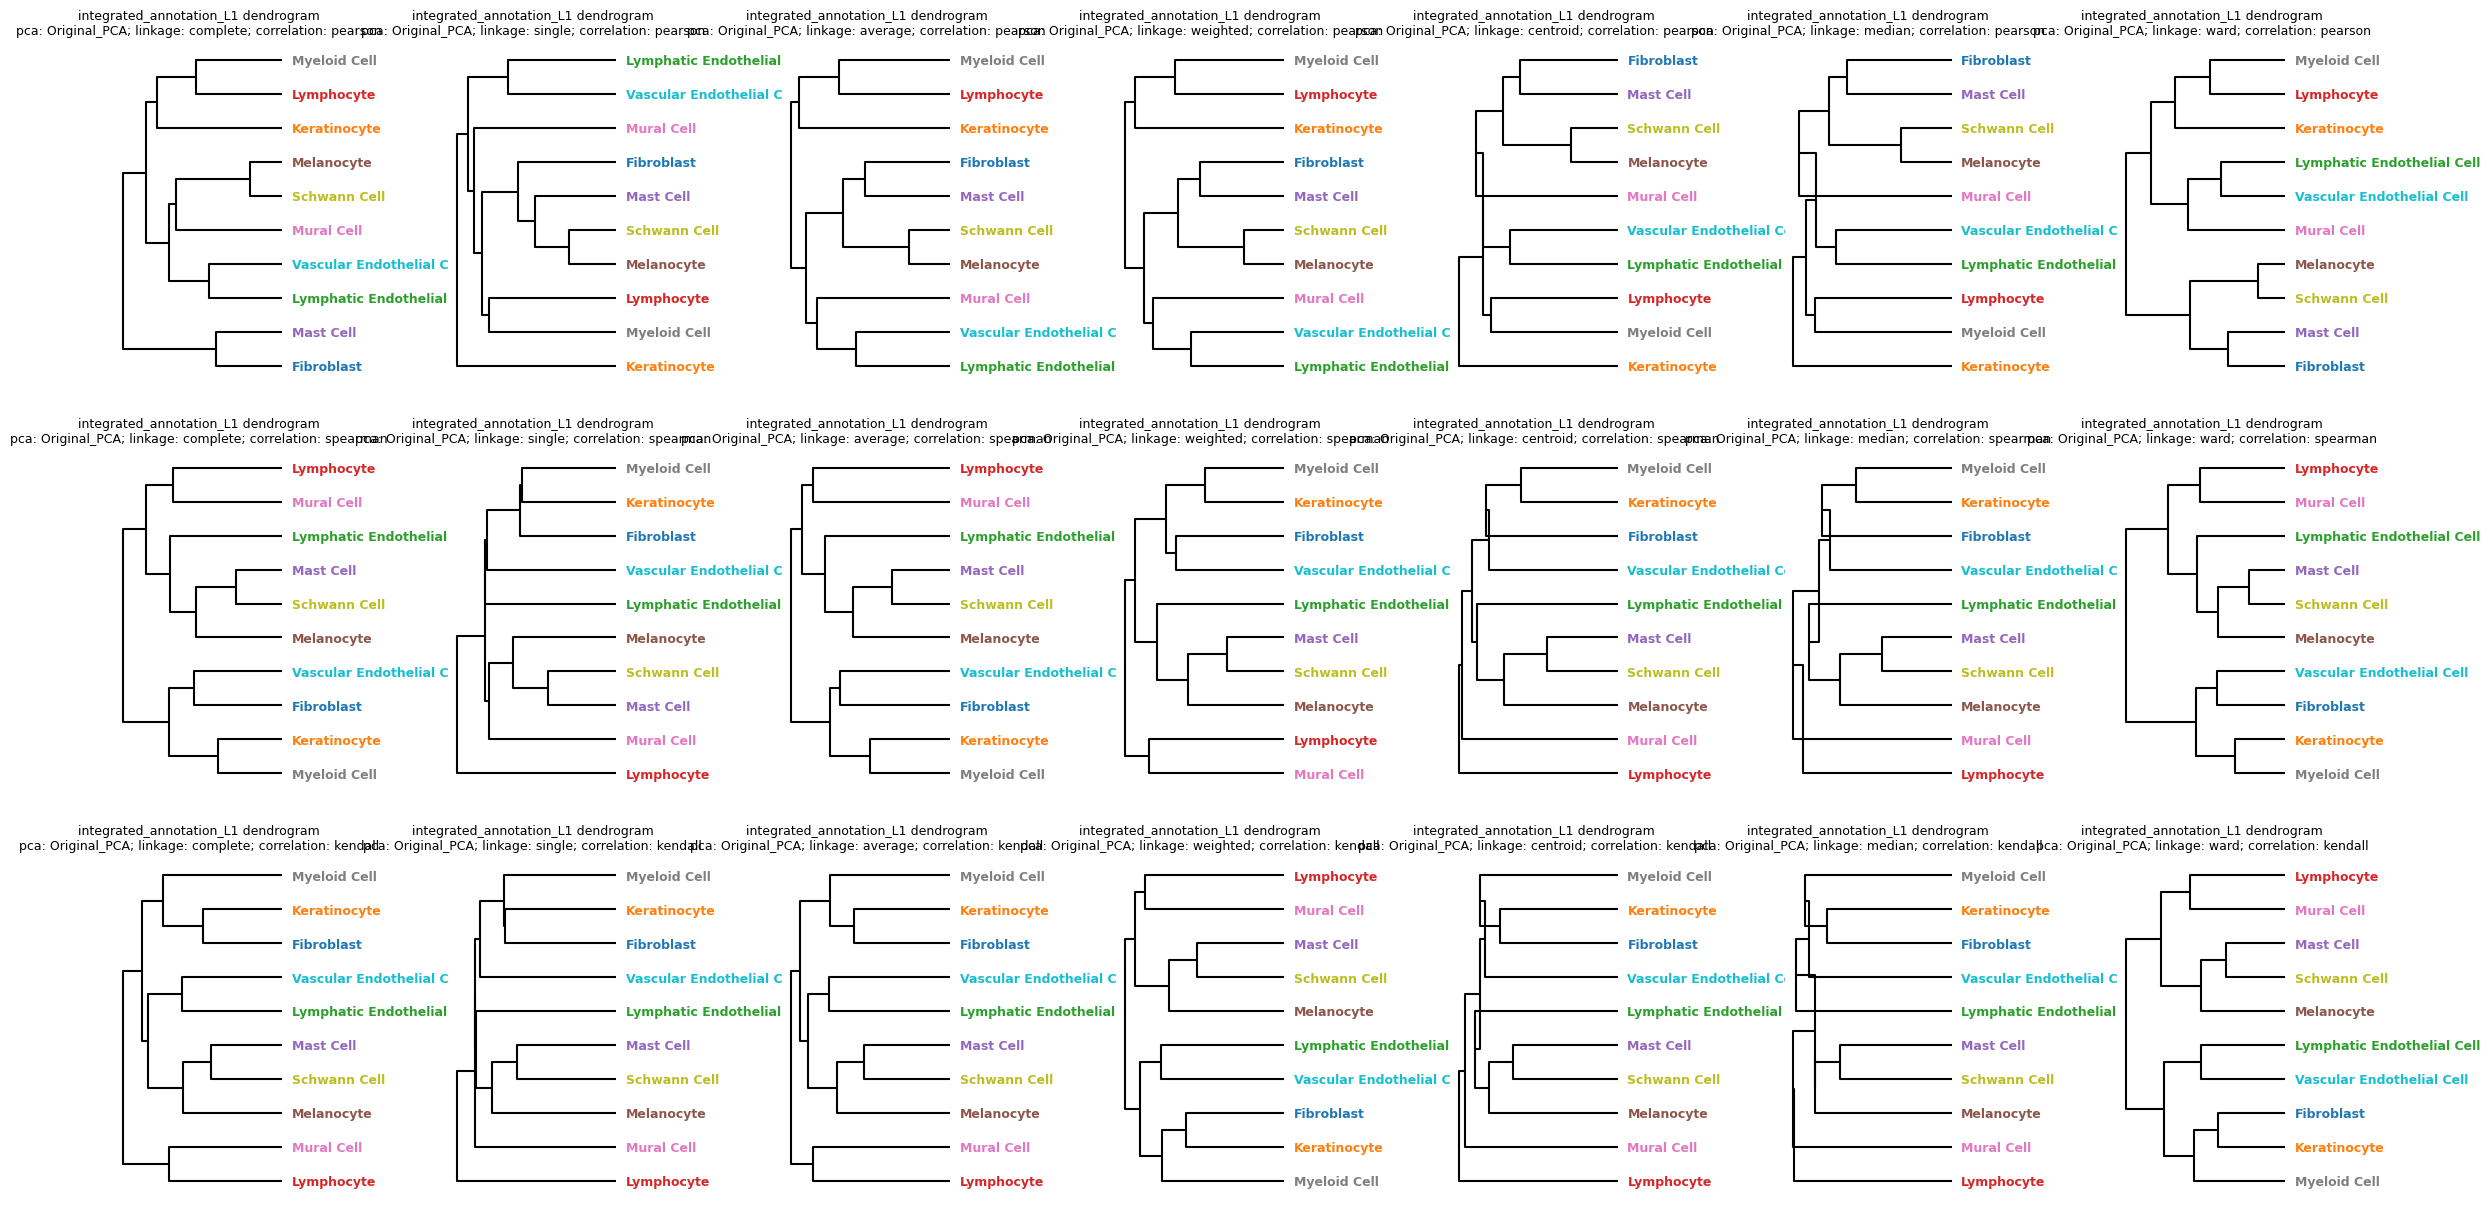

In [299]:
optimal_ordering = True
pca_name = 'Original_PCA'
cluster = 'integrated_annotation_L1'
linkage_methods = ['complete', 'single', 'average', 'weighted', 'centroid', 'median', 'ward']
correlation_methods = ['pearson', 'spearman', 'kendall']
fig, axes = initialize_subplots(groups_to_plot=len(linkage_methods)*len(correlation_methods), ncols = len(linkage_methods), figsize_multiplier = (4, 5), gridspec_kw = dict(wspace = 1))

for row, cor_method in enumerate(correlation_methods):
    for col, linkage_meth in enumerate(linkage_methods):
        ax = axes[row, col]
        make_dendrogram(adata = tmp_data, cluster = cluster, pca_name = pca_name, linkage_method = linkage_meth, cor_method = cor_method, optimal_ordering = optimal_ordering, ax = ax, full_cmap = cmap)

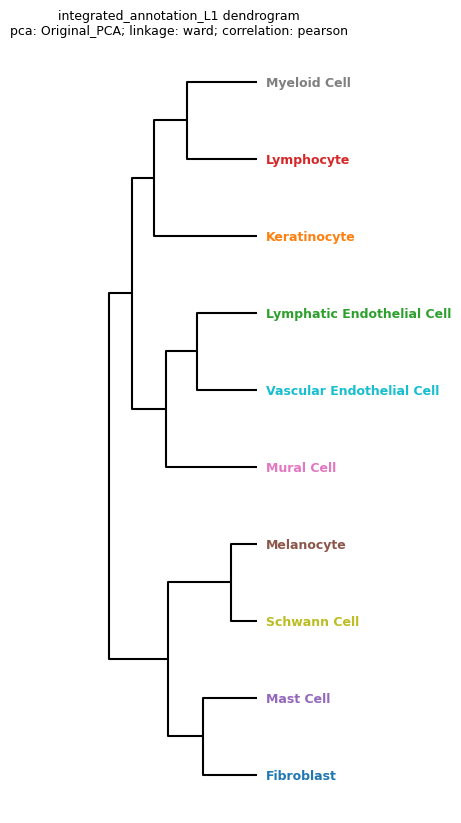

In [306]:
cluster = 'integrated_annotation_L1'
pca_name = 'Original_PCA'
cmap = {cl: tmp_data.uns[f'{cluster}_colors'][ix] for ix, cl in enumerate(tmp_data.obs[cluster].cat.categories)}
fig, ax = plt.subplots(figsize = (2, 10))
dendro = make_dendrogram(adata = tmp_data, cluster = cluster, pca_name = pca_name, linkage_method = 'ward', cor_method = 'pearson', optimal_ordering = True, full_cmap = cmap, ax = ax, return_dendrogram=True)

with open(os.path.join('/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/Dendrogram_data', f'First_level_dendrogram.pkl'), 'wb') as file:
    pickle.dump(dendro, file)
    
#[fig.savefig(os.path.join(fig_path, f'KCs_Dendrogram_Level3_Short.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

In [307]:
del tmp_data

# Per study QC

In [29]:
adata.var['mito'] = adata.var['feature_name'].str.startswith('MT-')
adata.var['ribo'] = adata.var['feature_name'].str.startswith(('RPS', 'RPL'))
sc.pp.calculate_qc_metrics(adata, qc_vars=['mito', 'ribo'], inplace=True, layer='raw_counts')

In [308]:
def add_annotations_2():
    # 1. Setup donor-to-index mapping for positioning
    donors = order # Using the 'order' list defined in your main block
    donor_to_idx = {donor: i for i, donor in enumerate(donors)}
    
    # --- CELL TYPE LEVEL ANNOTATIONS & MEANS ---
    # Group by Cell Type to find their start/end spans and overall mean
    for ct, sub_df in plot_df.groupby('integrated_annotation_L1', observed=True):
        ct_indices = [donor_to_idx[d] for d in sub_df[x].unique() if d in donor_to_idx]
        if not ct_indices: continue
        ct_start, ct_end = min(ct_indices), max(ct_indices)
        
        # Calculate mean for the ENTIRE cell type across all studies
        ct_mean = sub_df[y].mean()
        
        # Draw Mean line for this cell type
        # zorder=3 puts it IN FRONT of the violins (violins are typically zorder 1 or 2)
        ax.hlines(y=ct_mean, xmin=ct_start-0.5, xmax=ct_end+0.5, 
                  colors='k', linestyles=':', linewidth=1.5, zorder=-3)
        
        # Draw Vertical Separator at the end of the Cell Type block
        # zorder=0 keeps the separator lines in the background
        if ct_end < len(donors) - 1:
            ax.axvline(x=ct_end + 0.5, color='lightgray', linestyle='-', linewidth=1, zorder=0)
        
        # Draw brackets and text only on the bottom subplot
        if ix == (len(qc_metrics)-1):
            y_pos_ct = -0.35 
            
            # Draw the horizontal line for the Cell Type group
            ax.plot([ct_start, ct_end], [y_pos_ct, y_pos_ct], color='k', 
                    transform=ax.get_xaxis_transform(), clip_on=False, lw=0.5)
            
            # Add the Cell Type label
            ax.text((ct_start + ct_end) / 2, y_pos_ct - 0.05, ct, ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontweight='regular', fontsize=6)

    # Clean up spines
    [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
    if ix != 0:
        ax.spines['bottom'].set_visible(True) # Ensure bottom spine is there for the last plot

    # Return the original tick strings for the main loop to process
    return [str(d) for d in donors]

In [277]:
plot_df['study_fix_numbered'] = plot_df['study_fix_short'].str.replace('\n', '_')
study_map = {cl: f'{ix}: {cl}' for ix, cl in enumerate(natsorted(plot_df['study_fix_numbered'].unique()))}
plot_df['study_fix_numbered'] = plot_df['study_fix_numbered'].map(study_map)
plot_df['study_fix_numbered'] = plot_df['integrated_annotation_L1'].map(short_name).astype(str) + ' - ' + plot_df['study_fix_numbered'].astype(str)

## Fig S1c

[None, None]

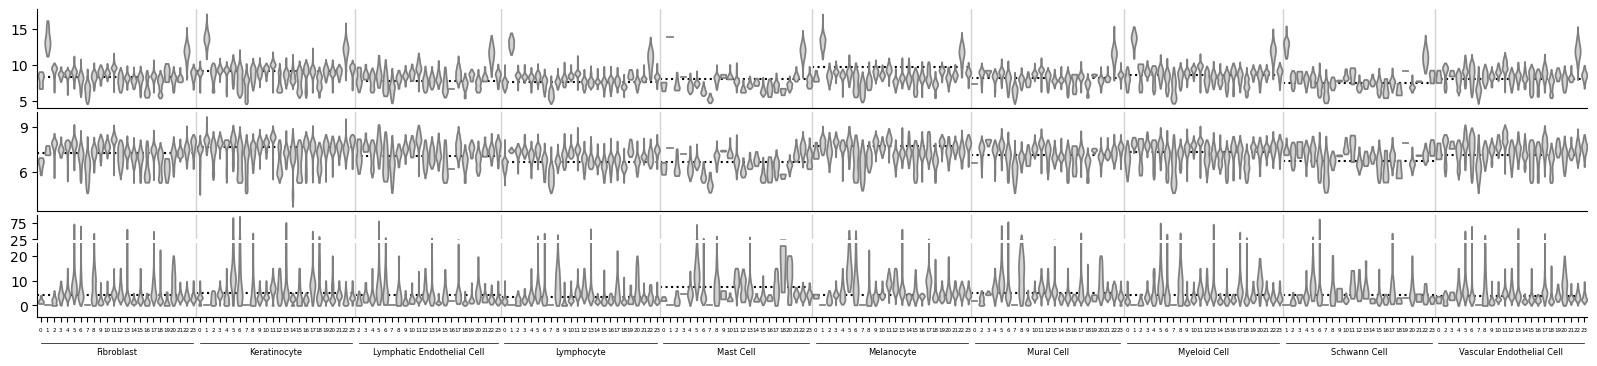

In [309]:
qc_metrics = ['log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_mito', 'pct_counts_mito']

y = 'log1p_total_counts'
x = 'study_fix_numbered'
hue = 'study_fix_numbered'

fig, axes = initialize_subplots(len(qc_metrics), ncols = 1, figsize_multiplier = (30, 1), gridspec_kw = dict(hspace = 0.05, height_ratios = [4,4,1,3]), sharex = False)

#order = plot_df.sort_values(by = x, key = natsorted)[x].unique()
order = natsorted(plot_df[x].unique())
for ix, y in enumerate(qc_metrics):
    print(y)
    clear_output(wait = True)
    ax = axes[ix]
    sbn.violinplot(data=plot_df, x=x, y=y, density_norm='width', cut=0, ax=ax, color = 'lightgray', inner = None, order = order)

    ticks = add_annotations_2()

    #ax.set_ylabel(ax.get_ylabel(), fontsize = 6)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    if ix != (len(qc_metrics)-1):
        #ticks = ax.get_xticklabels()
        ax.set_xticks([])
    else:
        #ax.set_xticklabels([t.get_text().split(' - ')[-1].split(':')[0] for t in ticks], fontsize = 8)
        ax.set_xticklabels([t.split(' - ')[-1].split(':')[0] for t in ticks], fontsize = 6)
    ax.set_xlim([-0.5, len(order)-0.5])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))
    ax.legend('', frameon = False)
    [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
    
break_point = 25
ax.set_ylim(top = break_point)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))

ax=axes[-2]
ax.set_ylim(bottom = break_point)
ax.spines['bottom'].set_visible(False)
#ax.set_xticks([])
ax.set_yticks([25, 75])
#ax.set_ylabel('Total counts, log(x+1)')
[fig.savefig(os.path.join(fig_path, f'QC_All_cells_by_CellType_studies_separated_total_genes_mito.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

In [324]:
for i in plot_df['study_fix_numbered'].str.split(' - ').str[1].unique().tolist():
    print(i, end = '; ')

0: Alkon 2022; 1: Belote 2021; 2: Boothby 2021; 3: Cheng 2018; 4: Dunlap 2022; 5: Gao 2021; 6: Gaydosik 2019; 7: He 2020; 8: Hughes 2020; 9: Ji 2020; 10: Kim 2020; 11: Liu 2025; 12: Rindler 2021; 13: Rojahn 2020; 14: Sole-Boldo 2020; 15: Tabib 2021; 16: Takahashi 2020; 17: Theocharidis 2022; 18: Vorstandlechner 2021; 19: Wang 2020; 20: Wiedemann 2023; 21: Xu 2022; 22: Yuan in prep; 23: Zou 2021; 

[None, None]

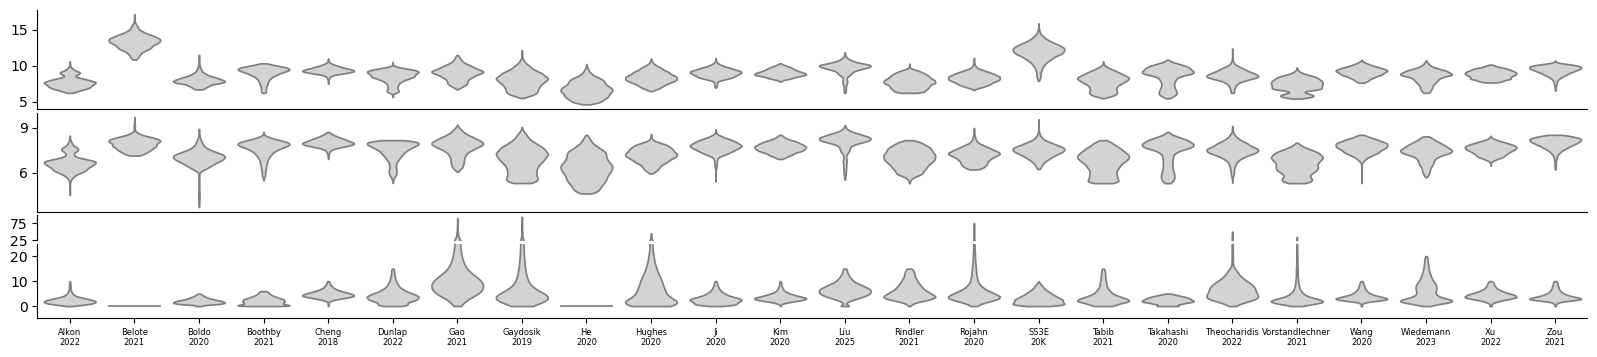

In [150]:
qc_metrics = ['log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_mito', 'pct_counts_mito']

y = 'log1p_total_counts'
x = 'study_id_short'
hue = 'integrated_annotation_L1'

fig, axes = initialize_subplots(len(qc_metrics), ncols = 1, figsize_multiplier = (20, 1), gridspec_kw = dict(hspace = 0.05, height_ratios = [4,4,1,3]), sharex = False)

order = plot_df.sort_values(by = 'study_id')[x].unique()
for ix, y in enumerate(qc_metrics):
    print(y)
    clear_output(wait = True)
    ax = axes[ix]
    sbn.violinplot(data=plot_df, x=x, y=y, density_norm='width', cut=0, ax=ax, color = 'lightgray', inner = None)#, order = order)

    #ticks = add_annotations()

    #ax.set_ylabel(ax.get_ylabel(), fontsize = 6)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    if ix != (len(qc_metrics)-1):
        ticks = ax.get_xticklabels()
        ax.set_xticks([])
    else:
        ax.set_xticklabels(order, fontsize = 6)
    #ax.set_xlim([-0.5, len(donors)-0.5])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))
    [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
    
break_point = 25
ax.set_ylim(top = break_point)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))

ax=axes[-2]
ax.set_ylim(bottom = break_point)
ax.spines['bottom'].set_visible(False)
#ax.set_xticks([])
ax.set_yticks([25, 75])
#ax.set_ylabel('Total counts, log(x+1)')
[fig.savefig(os.path.join(fig_path, f'QC_All_cells_by_Study_total_genes_mito.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

# Fix study names

In [23]:
study = 'study_id'
adata.obs['study_fix'] = adata.obs[study].astype(str).replace('Boldo_Lyko_CommunicationsBiology_2020', 'Sole-Boldo_Lyko_CommunicationsBiology_2020').replace('SS3E_Human_Skin_20K', 'Yuan_in prep').replace('Ning', 'Liu_2025')
adata.obs['study_fix_short'] = adata.obs['study_fix'].str.split('_').str[0] + ' ' + adata.obs['study_fix'].str.split('_').str[-1]

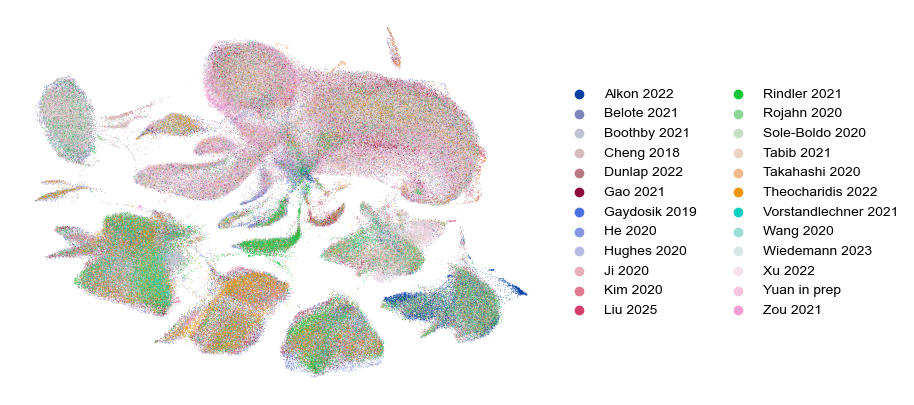

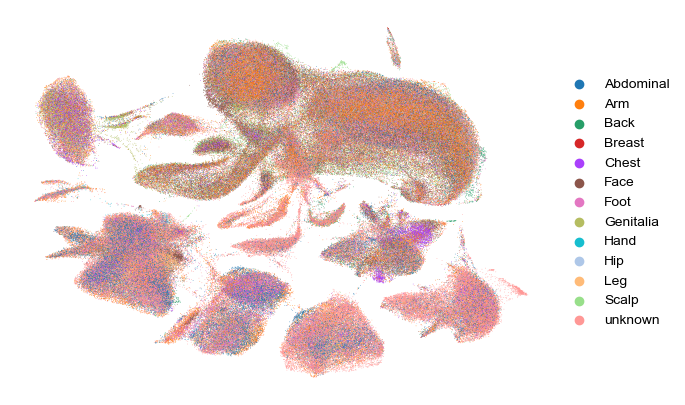

In [25]:
basis = 'integrated_UMAP_L1'

for color in ['study_fix_short', 'anatomical_region_level_2']:
    fig, ax = plt.subplots(figsize = (7, 5))
    sc.pl.embedding(adata, basis = basis, color = color, frameon = False, show = False, s = 1, title = '', ax = ax)

    #[fig.savefig(os.path.join('/mnt/p/users/Hao/iHSCA_manuscript/Figure_items', f'FULL_UMAP_{color}.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png']]

In [31]:
fig_path = '/mnt/p/users/Hao/iHSCA_manuscript/Figure_items/QC'
x = 'donor_id_running'
plot_df = adata.obs.copy()

plot_df["study_fix"] = pd.Categorical(
    plot_df["study_fix"],
    categories=natsorted(plot_df["study_fix"].dropna().unique()),
    ordered=True)

plot_df = plot_df.sort_values(by = 'study_fix')
plot_df[x] = plot_df[x].str.split('___').str[-1]
#plot_df['study_id_short'] = plot_df['study_id'].apply(lambda x: f'{x.split('_')[0]}\n{x.split('_')[-1]}')

In [27]:
def add_annotations(study_col = 'study_fix'):
    donors = plot_df[x].unique()
    donor_to_idx = {donor: i for i, donor in enumerate(donors)}
    ticks = []
    for study, sub_df in plot_df.groupby(study_col, observed=True):
        # Find the range of indices for this study
        indices = [donor_to_idx[d] for d in sub_df[x].unique()]
        start, end = min(indices), max(indices)
        study_mean = sub_df[y].mean()

        d_ix = -1
        for d in sub_df[x].unique():
            ticks.append(str(d_ix := d_ix+1))
       
        # Draw Background Mean Line (zorder=0 puts it behind violins)
        ax.hlines(y=study_mean, xmin=start-0.5, xmax=end+0.5, 
                  colors='k', linestyles=':', linewidth=1, zorder=0)
        
        # Draw Vertical Separator (at the end of the study block)
        if end < len(donors) - 1:
            ax.axvline(x=end + 0.5, color='lightgray', linestyle='-', linewidth=1)
        
        # 4. Add Study Annotations below X-axis
        # Position is slightly below the plot (adjust y_pos based on your data scale)
        y_min, y_max = ax.get_ylim()
        y_pos = -0.3
        
        if ix == (len(qc_metrics)-1):
            # Horizontal line under donors
            ax.plot([start, end], [y_pos, y_pos], color='black', transform=ax.get_xaxis_transform(), clip_on=False)
            # Study ID Text
            ax.text((start + end) / 2, y_pos+(y_pos/2), f'{study.split('_')[0]}\n{study.split('_')[-1]}', ha='center', va='top', 
                    transform=ax.get_xaxis_transform(), fontweight='regular', fontsize = 6, rotation = 90)
        [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
        if ix == 0:
            [ax.spines[spine].set_visible(False) for spine in ['top', 'right']]
        else:
            [ax.spines[spine].set_visible(False) for spine in ['right']]
    return ticks

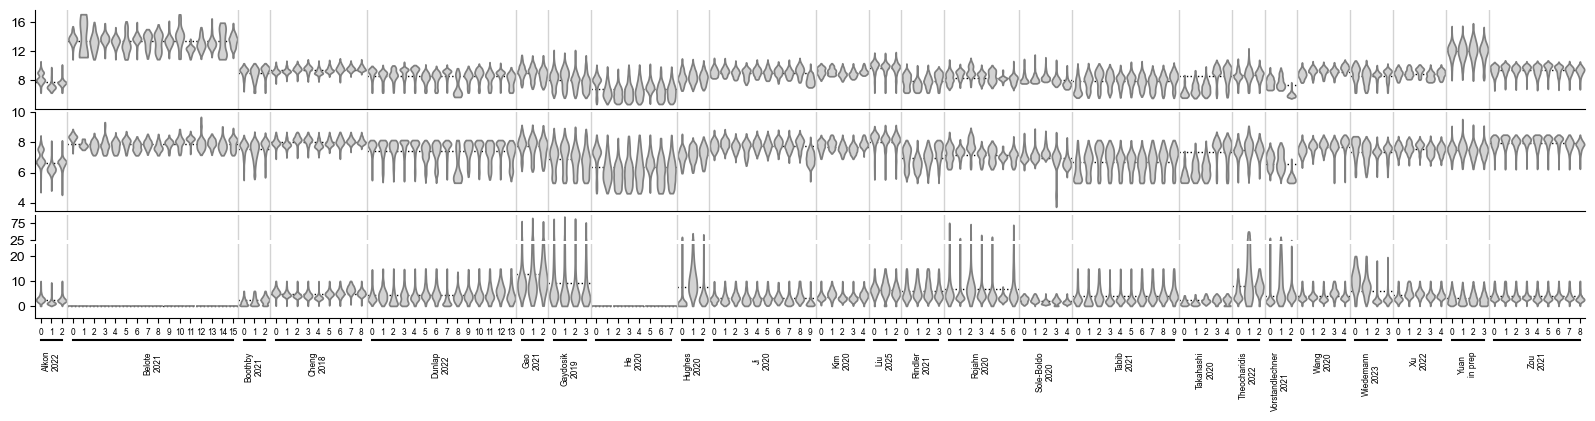

In [32]:
from matplotlib.ticker import MaxNLocator

qc_metrics = ['log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_mito', 'pct_counts_mito']
fig, axes = initialize_subplots(len(qc_metrics), ncols = 1, figsize_multiplier = (20, 1), gridspec_kw = dict(hspace = 0.05, height_ratios = [4,4,1,3]), sharex = False)

order = plot_df.sort_values(by = 'study_fix_short')['donor_id_running'].unique()
for ix, y in enumerate(qc_metrics):
    print(y)
    clear_output(wait = True)
    ax = axes[ix]
    sbn.violinplot(data=plot_df, x=x, y=y, density_norm='width', cut=0, ax=ax, color = 'lightgray', inner = None, order = order)

    ticks = add_annotations()

    #ax.set_ylabel(ax.get_ylabel(), fontsize = 6)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    if ix != (len(qc_metrics)-1):
        ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(ticks, fontsize = 6)
    ax.set_xlim([-0.5, len(order)-0.5])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 4))
    
break_point = 25
ax.set_ylim(top = break_point)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))

ax=axes[-2]
ax.set_ylim(bottom = break_point)
ax.spines['bottom'].set_visible(False)
#ax.set_xticks([])
ax.set_yticks([25, 75])
#ax.set_ylabel('Total counts, log(x+1)')
#[fig.savefig(os.path.join(fig_path, f'QC_All_cells_by_donor_total_genes_mito_alphabetical.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]

## Separate SS3xpress dataset samples

In [33]:
plot_df['donor_qc'] = pd.NA
plot_df['donor_qc'] = plot_df['donor_qc'].fillna(plot_df[plot_df['study_fix_short'] == 'Yuan in prep'][['anatomical_region_level_3', 'donor_id_running']].apply(lambda x: x[1] + '_' + x[0], axis = 1))
plot_df['donor_qc'] = plot_df['donor_qc'].fillna(plot_df['donor_id_running'])

In [34]:
sbn.color_palette('Blues', n_colors=8)[2:6]

[(0.6718954248366014, 0.8143790849673203, 0.9006535947712418),
 (0.5105882352941177, 0.7323029603998462, 0.8588389081122645),
 (0.34646674356016915, 0.632402921953095, 0.8106728181468666),
 (0.21568627450980393, 0.5294117647058824, 0.7542483660130719)]

In [35]:
donor_cmap = {
    'donor1_Inner upper arm': '#a2dafc',
    'donor1_Occipital': '#75c7fa',
    'donor1_Plantar': '#56bdfc',
    'donor1_Upper back': '#2baeff',
    'donor2_Inner upper arm': '#a2dafc',
    'donor2_Occipital': '#75c7fa',
    'donor2_Plantar': '#56bdfc',
    'donor2_Upper back': '#2baeff',
    'donor4_Inner upper arm': '#a2dafc',
    'donor4_Occipital': '#75c7fa',
    'donor4_Plantar': '#56bdfc',
    'donor4_Upper back': '#2baeff',
    'donor5_Inner upper arm': '#a2dafc',
    'donor5_Occipital': '#75c7fa',
    'donor5_Plantar': '#56bdfc',
    'donor5_Upper back': '#2baeff'
}
donor_cmaps = {'donor1': 'Blues', 'donor2': 'Reds', 'donor4': 'Purples', 'donor5': 'Greens'}
donor_cmap = {cl: mpl.colors.rgb2hex(sbn.color_palette(donor_cmaps[cl.split('_')[0]], n_colors = 10)[2:6][ix%4]) for ix, cl in enumerate(natsorted(plot_df[plot_df['study_fix_short'] == 'Yuan in prep']['donor_qc'].unique()))}
print(donor_cmap)
donor_cmap = {cl: 'lightgray' if cl not in donor_cmap else donor_cmap[cl] for cl in plot_df['donor_qc'].unique()}

{'donor1_Inner upper arm': '#bfd8ed', 'donor1_Occipital': '#a1cbe2', 'donor1_Plantar': '#7db8da', 'donor1_Upper back': '#5ca4d0', 'donor2_Inner upper arm': '#fcb499', 'donor2_Occipital': '#fc9576', 'donor2_Plantar': '#fb7858', 'donor2_Upper back': '#f7593f', 'donor4_Inner upper arm': '#d5d5e9', 'donor4_Occipital': '#bebfdd', 'donor4_Plantar': '#a9a7cf', 'donor4_Upper back': '#9390c3', 'donor5_Inner upper arm': '#c1e6ba', 'donor5_Occipital': '#a4da9e', 'donor5_Plantar': '#84cc83', 'donor5_Upper back': '#62bb6d'}


## Fig S1b

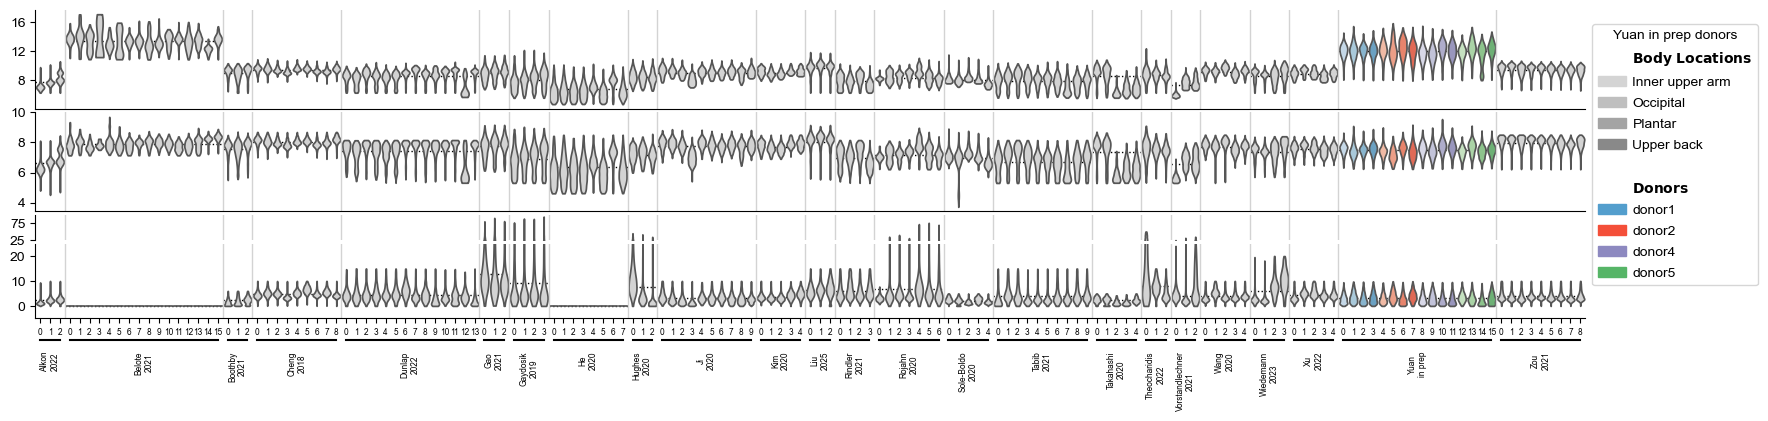

In [36]:
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
x = 'donor_qc'
qc_metrics = ['log1p_total_counts', 'log1p_n_genes_by_counts', 'pct_counts_mito', 'pct_counts_mito']
fig, axes = initialize_subplots(len(qc_metrics), ncols = 1, figsize_multiplier = (20, 1), gridspec_kw = dict(hspace = 0.05, height_ratios = [4,4,1,3]), sharex = False)

order = plot_df.sort_values(by = ['study_fix_short', 'donor_qc'])[x].unique()
for ix, y in enumerate(qc_metrics):
    print(y)
    clear_output(wait = True)
    ax = axes[ix]
    sbn.violinplot(data=plot_df, x=x, y=y, density_norm='width', cut=0, ax=ax, color = 'lightgray', inner = None, order = order, palette = donor_cmap)

    ticks = add_annotations()

    #ax.set_ylabel(ax.get_ylabel(), fontsize = 6)
    ax.set_ylabel('')
    ax.set_xlabel('')
    
    if ix != (len(qc_metrics)-1):
        ax.set_xticks([])
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(ticks, fontsize = 6)
    ax.set_xlim([-0.5, len(order)-0.5])
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 4))
    
break_point = 25
ax.set_ylim(top = break_point)
ax.spines['top'].set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins = 3))

ax=axes[-2]
ax.set_ylim(bottom = break_point)
ax.spines['bottom'].set_visible(False)
#ax.set_xticks([])
ax.set_yticks([25, 75])

loc_colors = sbn.color_palette('Greys', n_colors=10)[2:6]
loc_labels = ['Inner upper arm', 'Occipital', 'Plantar', 'Upper back']
"""donor_handles = [mpatches.Patch(color=sbn.color_palette(p, n_colors=6)[2], label=d) 
                 for d, p in donor_cmaps.items()]
loc_handles = [mpatches.Patch(color=loc_colors[i], label=loc_labels[i]) 
               for i in range(len(loc_labels))]

leg1 = ax.legend(handles=loc_handles, title="Body Locations", bbox_to_anchor=(1.2, 9))
ax.add_artist(leg1)
leg2 = ax.legend(handles=donor_handles, title="Donors",  bbox_to_anchor=(1, 3))"""

handles = []
labels = []

handles.append(mpatches.Patch(color='none', label='')) 
labels.append(r'$\bf{Body\ Locations}$') # Bold title using LaTeX

for i in range(len(loc_labels)):
    handles.append(mpatches.Patch(color=loc_colors[i]))
    labels.append(loc_labels[i])

handles.append(mpatches.Patch(color='none', label=''))
labels.append('')

handles.append(mpatches.Patch(color='none', label=''))
labels.append(r'$\bf{Donors}$')

for d, p in donor_cmaps.items():
    color = sbn.color_palette(p, n_colors=6)[3]
    handles.append(mpatches.Patch(color=color))
    labels.append(d)

ax.legend(handles, labels, title = 'Yuan in prep donors',
          loc='upper left', 
          bbox_to_anchor=(1, 9), 
          frameon=True, 
          handletextpad=0.5, 
          labelspacing=0.6)

#ax.set_ylabel('Total counts, log(x+1)')
#[fig.savefig(os.path.join(fig_path, f'QC_All_cells_by_donor_total_genes_mito_alphabetical_SS3_Bodysites.{f}'), bbox_inches = 'tight', dpi = 600) for f in ['png', 'pdf']]